In [1]:
import matplotlib.pyplot as plt
import numpy as np
import json
from pathlib import Path
import pandas as pd

In [ ]:
log_dir = Path.cwd() / 'logs'
# list all folders in log_dir
run_dirs = [f for f in log_dir.iterdir() if f.is_dir()]
full_df = None
for run_dir in run_dirs:
    print(run_dir.name)
    results_file = list(run_dir.glob("*results.json"))
    assert len(results_file) == 1
    results_file = results_file[0]
    with results_file.open("r", encoding="utf-8") as f:
        data = json.load(f)
        print(len(data))
        run_data = data[-1]
        history_df = pd.DataFrame(run_data["history"])
        if full_df is None:
            full_df = history_df
        else:
            full_df = pd.concat([full_df, history_df], ignore_index=True)

display(full_df)

baseline_lambda_0.0
1
baseline_lambda_0.1
2
baseline_lambda_1.0
3
baseline_lambda_10.0
4
baseline_lambda_100.0
5


,epoch,lambda_embed,gamma_uniform,use_word_aware_loss,use_uniform_loss,embedding_source,embed_loss_type,val_loss,val_ce_loss,val_embed_loss,...,val_n_aux_vecs,gen_bleu,gen_chrfpp,gen_n_eval_examples,gen_bertscore_f1,train_loss,train_ce_loss,train_embed_loss,train_uniform_loss,train_n_aux_vecs
0,0,0.0,0.0,False,False,input,cosine,2.536541,2.536541,0.179792,...,493.853322,19.370522,40.454873,160,0.496226,NaN,NaN,NaN,NaN,NaN
1,1,0.0,0.0,False,False,input,cosine,2.078545,2.078545,0.159512,...,493.853322,22.761477,42.507441,160,0.533346,2.301446,2.301446,0.170500,0.0,499.394458
2,2,0.0,0.0,False,False,input,cosine,2.003571,2.003571,0.154892,...,493.853322,23.222290,43.536391,160,0.539690,1.996261,1.996261,0.155499,0.0,499.389965
3,3,0.0,0.0,False,False,input,cosine,1.977576,1.977576,0.152856,...,493.853322,23.844953,43.775429,160,0.543626,1.790927,1.790927,0.144253,0.0,499.400556
4,4,0.0,0.0,False,False,input,cosine,1.969305,1.969305,0.152269,...,493.853322,23.860887,44.391608,160,0.544411,1.645683,1.645683,0.135968,0.0,499.392853
5,5,0.0,0.0,False,False,input,cosine,1.972664,1.972664,0.152372,...,493.853322,23.750582,43.757957,160,0.545583,1.539298,1.539298,0.129585,0.0,499.390821
6,6,0.0,0.0,False,False,input,cosine,1.977594,1.977594,0.152425,...,493.853322,23.335250,43.737198,160,0.549462,1.462654,1.462654,0.124799,0.0,499.399914
7,0,0.1,0.0,False,False,input,cosine,2.554520,2.536541,0.179792,...,493.853322,19.370522,40.454873,160,0.496226,NaN,NaN,NaN,NaN,NaN
8,1,0.1,0.0,False,False,input,cosine,2.092719,2.076875,0.158449,...,493.853322,23.039118,43.178791,160,0.542721,2.318267,2.301282,0.169859,0.0,499.396277
9,2,0.1,0.0,False,False,input,cosine,2.016574,2.001370,0.152040,...,493.853322,22.854207,43.155960,160,0.546167,2.011347,1.996020,0.153267,0.0,499.392853


C:\Users\KatherynZhou\AppData\Local\Temp\ipykernel_63508\817996148.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("plasma")


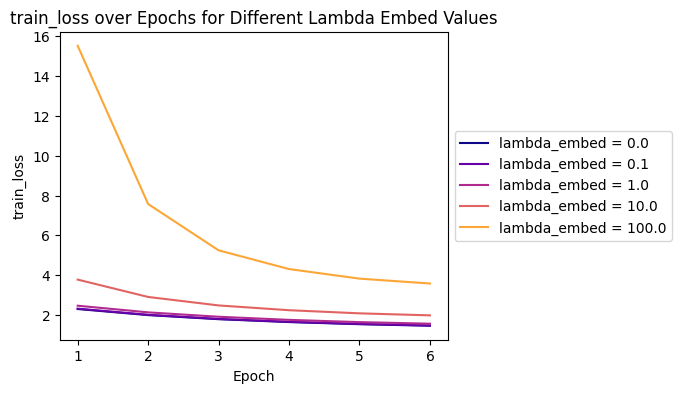

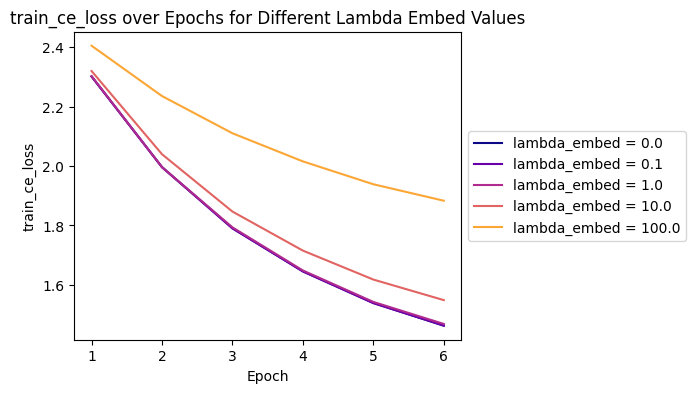

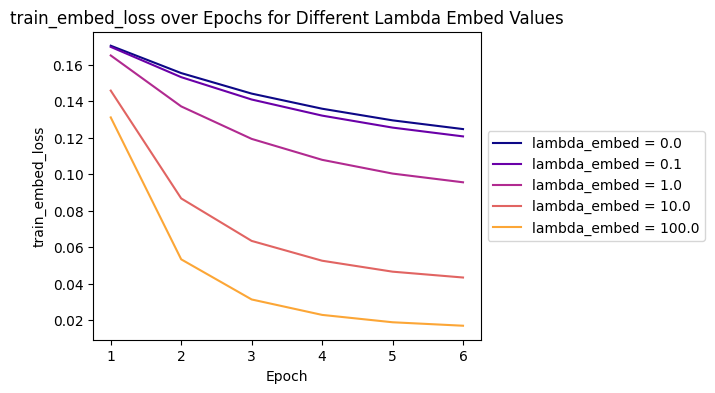

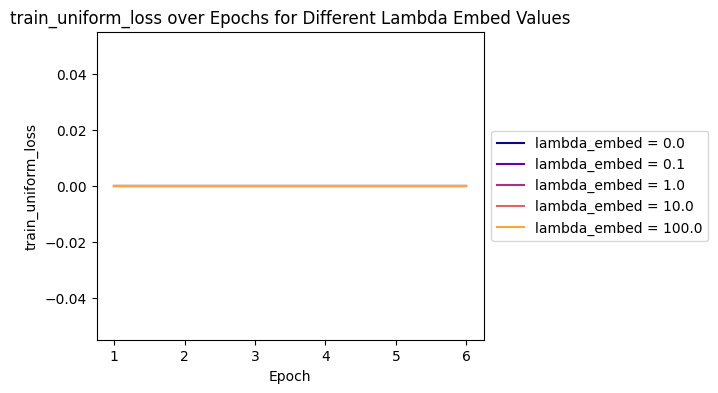

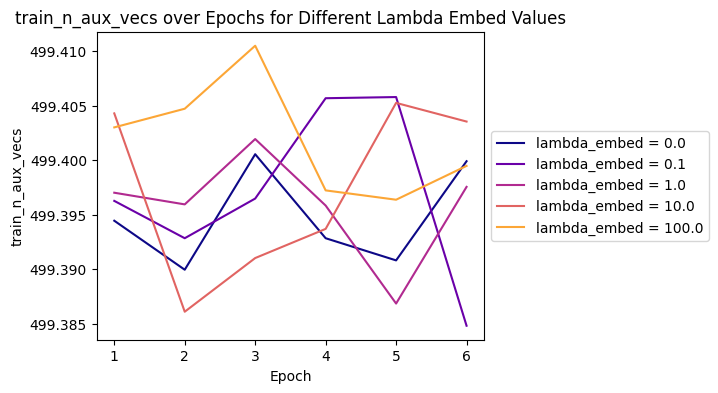

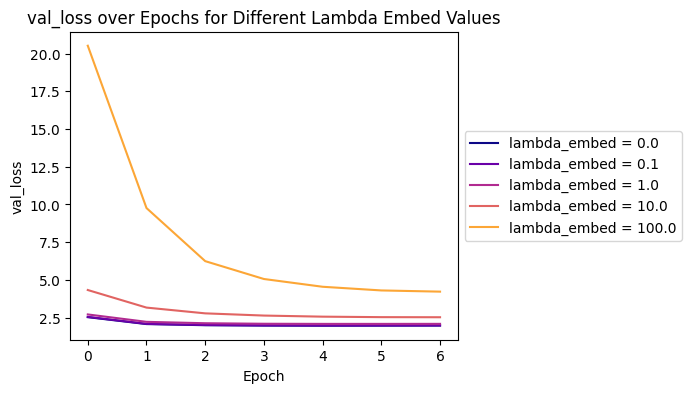

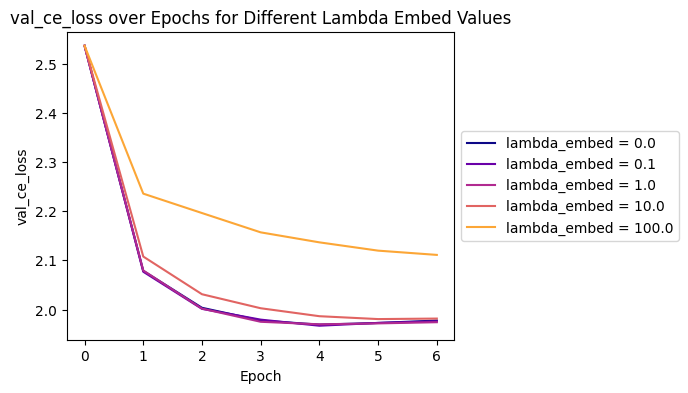

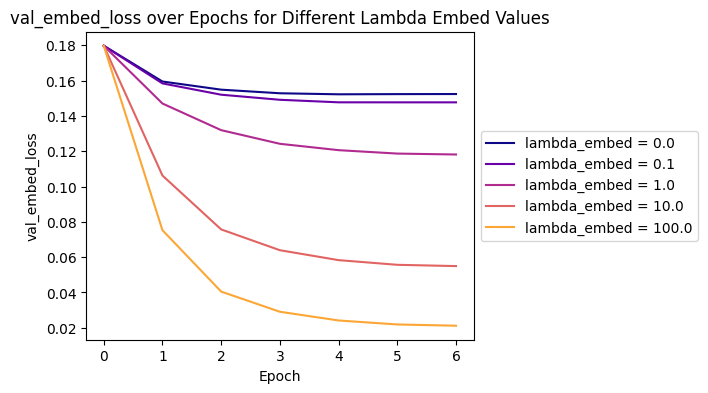

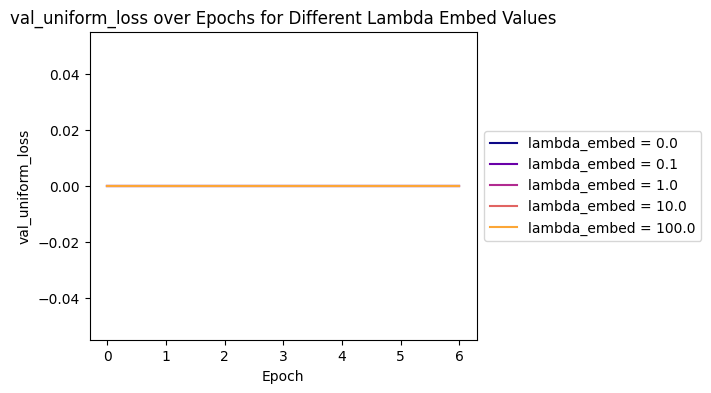

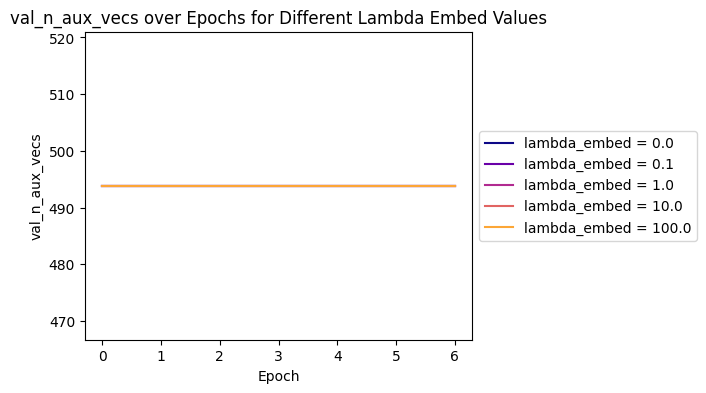

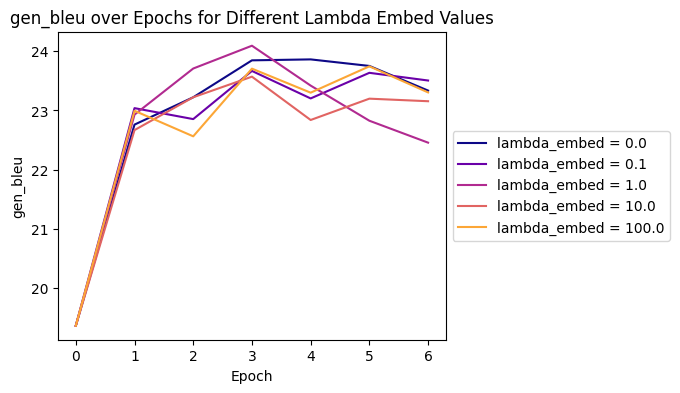

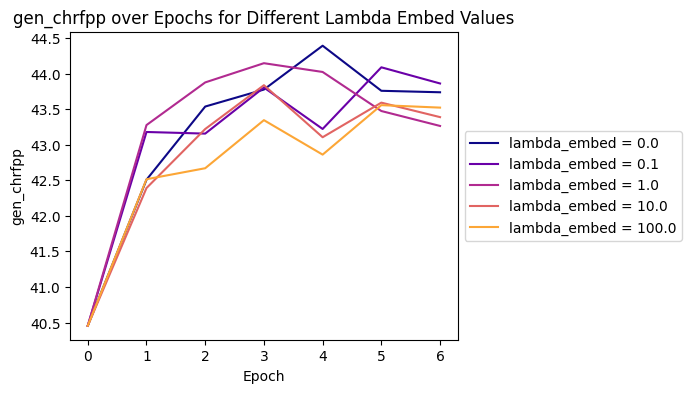

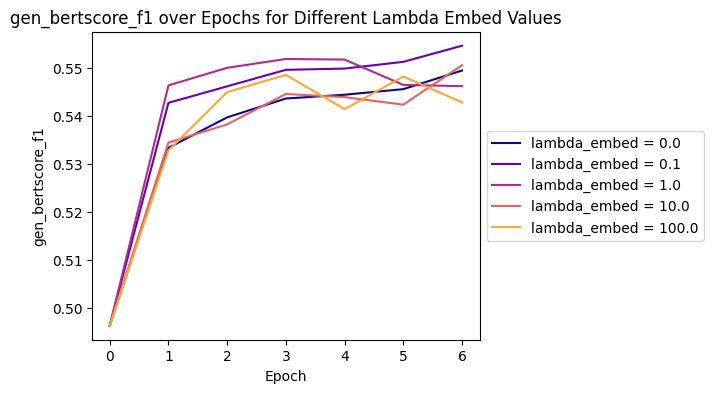

In [3]:
lambda_vals = full_df["lambda_embed"].unique()

for metric in ['train_loss', 'train_ce_loss', 'train_embed_loss', 'train_uniform_loss', 'train_n_aux_vecs', 'val_loss', 'val_ce_loss', 'val_embed_loss', 'val_uniform_loss', 'val_n_aux_vecs', 'gen_bleu', 'gen_chrfpp', 'gen_bertscore_f1']:
    # create a new figure for this metric
    plt.figure(figsize=(5, 4))
    # set color map to magma, set each line to a different color evenly spaced across the color map:
    cmap = plt.cm.get_cmap("plasma")
    for i, lambda_val in enumerate(lambda_vals):
        lambda_df = full_df[full_df["lambda_embed"] == lambda_val]
        plt.plot(lambda_df["epoch"], lambda_df[metric], 
                label=f'lambda_embed = {lambda_val}',
                color=cmap(i / len(lambda_vals))
                )
    # put legend outside of the plot:
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(f"{metric} over Epochs for Different Lambda Embed Values")